Total frames: 236
Mean latency: 22.14 ms
Median latency: 20.00 ms
Max latency: 63.00 ms
Min latency: 10.00 ms
Plot saved as c:\Users\nahom\Documents\actual_ground_removal_latency_vs_time.png


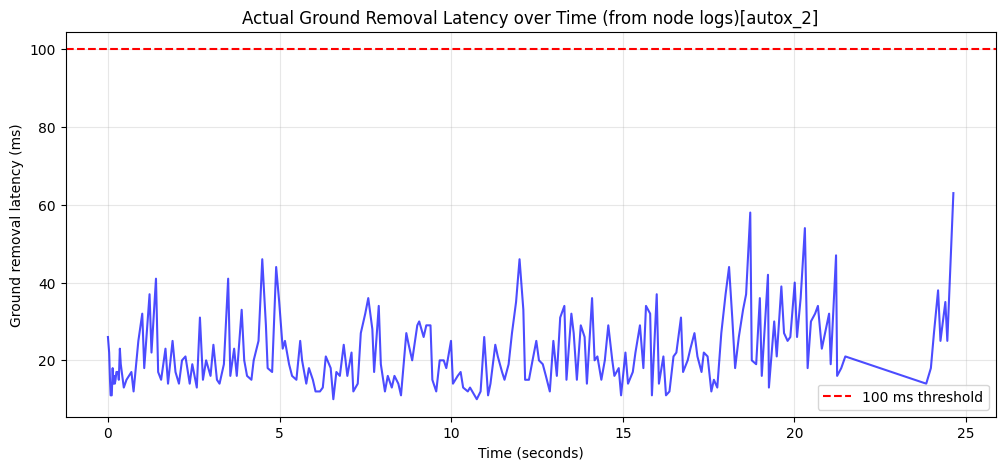

In [4]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os

try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

log_file = os.path.join(script_dir, "ground_removal_latencies.log")
pattern = r"\[INFO\] \[([\d\.]+)\].*GROUND_REMOVAL_LATENCY: (\d+) ms"

if not os.path.isfile(log_file):
    raise FileNotFoundError(f"Log file not found: {log_file}")

times = []
latencies = []
with open(log_file, "r", encoding="utf-8") as f:
    for line in f:
        match = re.search(pattern, line)
        if match:
            t = float(match.group(1))
            lat = int(match.group(2))
            times.append(t)
            latencies.append(lat)

if not times:
    print("No latency data found in log file")
else:
    # Sort by time (just in case)
    sorted_indices = np.argsort(times)
    times = np.array(times)[sorted_indices]
    latencies = np.array(latencies)[sorted_indices]

    # Optionally shift time to start from zero
    start_time = times[0]
    times_relative = times - start_time

    print(f"Total frames: {len(latencies)}")
    print(f"Mean latency: {np.mean(latencies):.2f} ms")
    print(f"Median latency: {np.median(latencies):.2f} ms")
    print(f"Max latency: {np.max(latencies):.2f} ms")
    print(f"Min latency: {np.min(latencies):.2f} ms")

    plt.figure(figsize=(12, 5))
    plt.plot(times_relative, latencies, 'b-', alpha=0.7)
    plt.axhline(y=100, color='r', linestyle='--', label='100 ms threshold')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Ground removal latency (ms)')
    plt.title('Actual Ground Removal Latency over Time (from node logs)[autox_2]')
    plt.legend()
    plt.grid(True, alpha=0.3)
    output_path = os.path.join(script_dir, 'actual_ground_removal_latency_vs_time.png')
    plt.savefig(output_path, dpi=150)
    print(f"Plot saved as {output_path}")
    plt.show()